# 💻 **Actividad 1**

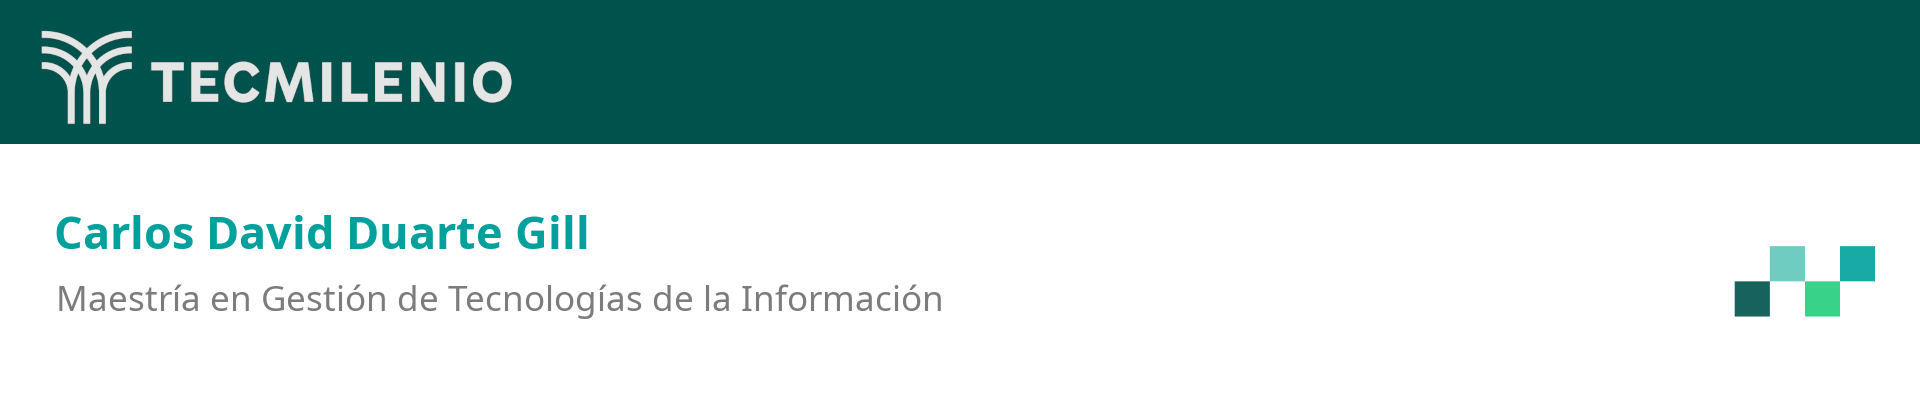

## **Visualización efectiva de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Félix Eduardo Bueno Pascual
- Fecha:  domingo 18 de enero de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 🔤 Introducción

La presente actividad constituye un ejercicio de integración entre la ciencia de datos y la psicología cognitiva. En un entorno saturado de información, la visualización de datos deja de ser una tarea estética para convertirse en una herramienta crítica de análisis y comunicación. El objetivo primordial es transformar registros crudos en narrativas visuales que respeten los límites de la carga cognitiva humana y potencien la detección de patrones estratégicos.

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la actividad, se ha diseñado un conjunto de datos basado en un escenario de Gestión de Experiencia del Cliente en Retail. Este dataset permite analizar la relación entre el comportamiento de compra, la logística y la percepción del usuario.

# 💻 Actividad 1: Fundamentos de visualización efectiva de datos

## 🧰 Carga de todas las librerías necesarias

 A continuación se importan las librerías necesarias para el análisis y la visualización.

### 📚 Librerías

In [151]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# warnings
import warnings
warnings.filterwarnings('ignore')

print("-" * 80)
print("Librerias importadas!")
print("-" * 80)

--------------------------------------------------------------------------------
Librerias importadas!
--------------------------------------------------------------------------------


### 🗂 Variables de entorno

In [152]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# estilo de las graficas
sns.set_style("white")
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_tecmi_dark="#00534c"
_color_teal="#20c997"
# colores generales
_color_purple="#6f42c1"
_color_pink="#e83e8c"
_color_orange="#fd7e14"
# colores boostrap
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"
# tamaños de fuente
_fontsize_title = 16
_fontsize_label = 12
_fontsize_marker = 9
# paletas de colores prearmadas
_paleta_tecmi = [_color_tecmi_light, _color_purple, _color_warning, _color_info, _color_primary]
_paleta_secundaria = [_color_tecmi_light, _color_primary, _color_purple]

print("-" * 80)
print("Variables de entorno cargadas!")
print("-" * 80)

--------------------------------------------------------------------------------
Variables de entorno cargadas!
--------------------------------------------------------------------------------


## 💾 Preparación de los datos

Para iniciar el análisis, cargaremos el conjunto de datos simulado desde un repositorio publico en **GitHub**.
El dataset simulado ha sido cargado previamente en el repositorio.

### 🗂 Carga del dataset

In [153]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# libreria con el dataset
# URL pública del dataset
url_dataset = "https://raw.githubusercontent.com/RamRider89/visualizacion-datos/refs/heads/main/actividad-1/actividad-1-data.csv"

# Carga de datos directamente a un DataFrame de Pandas
df = pd.read_csv(url_dataset)

### 🗂 Descripción del dataframe

In [154]:
print("\n" + "="*80)
print("\033[1m --- Estructura inicial del DataFrame --- \033[0m")
print("="*80)
df.head()


 --- Estructura inicial del DataFrame --- 


,ID,Categoria_Producto,Nivel_Prioridad,Tickets_Soporte,Monto_Venta_USD
0,1,Electrónica,Alta,2,1250.50
1,2,Hogar,Media,0,320.00
2,3,Moda,Baja,1,45.99
3,4,Deportes,Crítica,0,180.75
4,5,Electrónica,Media,3,890.00


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  150 non-null    int64  
 1   Categoria_Producto  150 non-null    object 
 2   Nivel_Prioridad     150 non-null    object 
 3   Tickets_Soporte     150 non-null    int64  
 4   Monto_Venta_USD     150 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 6.0+ KB


In [156]:
# nombres de columnas
_ID_Prod_ = 'ID'
_HouseAge_ = 'HouseAge'
_Categoria_Producto_ = 'Categoria_Producto'
_Nivel_Prioridad_ = 'Nivel_Prioridad'
_Tickets_Soporte_ = 'Tickets_Soporte'
# target
_Monto_Venta_USD_ = 'Monto_Venta_USD'

### 🔍 Información de la estructura

In [157]:
print("-" * 80)
print("\033[1m --- Dataset cargado correctamente --- \033[0m")
print("-"*80)
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

--------------------------------------------------------------------------------
 --- Dataset cargado correctamente --- 
--------------------------------------------------------------------------------
Dataset shape: (150, 5)
Número de filas: 150
Número de columnas: 5


## 📉 Visualizacion 1

Esta visualización tiene el proposito de comparar las magnitudes mediante un gráfico de barras. 
De esta manera se podra comparar el volumen total de ventas por categoría de producto para identificar el motor económico del negocio.

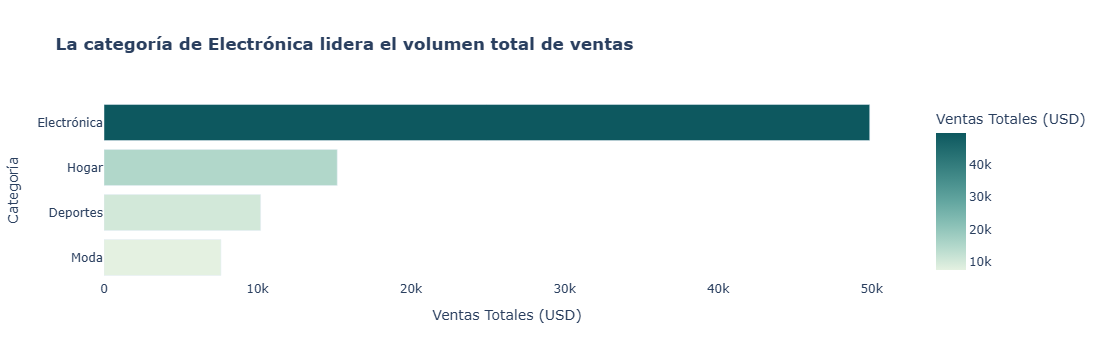

In [158]:
# grafico 1
# -------------------------------------------------------------------------------

# agrupacion de datos y ordenamiento
df_ventas = df.groupby(_Categoria_Producto_)[_Monto_Venta_USD_].sum().reset_index().sort_values(_Monto_Venta_USD_, ascending=True)

# titulo y legendas
title = '<b>La categoría de Electrónica lidera el volumen total de ventas</b>'
labels = {
       _Monto_Venta_USD_: 'Ventas Totales (USD)', 
       _Categoria_Producto_: 'Categoría'}

# definimos la grafica
fig1 = px.bar(df_ventas, 
             x=_Monto_Venta_USD_, 
             y=_Categoria_Producto_,
             orientation='h',
             title=title,
             labels=labels,
             color=_Monto_Venta_USD_,
             color_continuous_scale='Mint')

# se establece el color de fondo del layout
fig1.update_layout(showlegend=False, plot_bgcolor=_color_white)
fig1.show()

### 📑 Justificación Técnica

Las variables utilizadas en este gráfico son: 
- Categoría como variable nominal.
- Monto de Venta, como variable continua.

El gráfico utiliza los canales de longitud y posición en escala común, considerados los más precisos para la percepción humana y se aplicó un ordenamiento ascendente para reducir la carga cognitiva al buscar el valor máximo.

Se eligió un Gráfico de Barras Horizontales en orden ascendente para guiar el ojo hacia el valor máximo. Se descartó el gráfico de sectores en pastel debido a la dificultad del cerebro para comparar áreas y ángulos con precisión, especialmente con más de tres categorías, evitando así errores en la estimación de proporciones.

## 📉 Visualizacion 2

En la visualización 2 se busca determinar si existe una correlación entre el valor de la venta y la complejidad del soporte técnico (número de tickets). Para lograr esto utilizaremos un Gráfico de Dispersión.

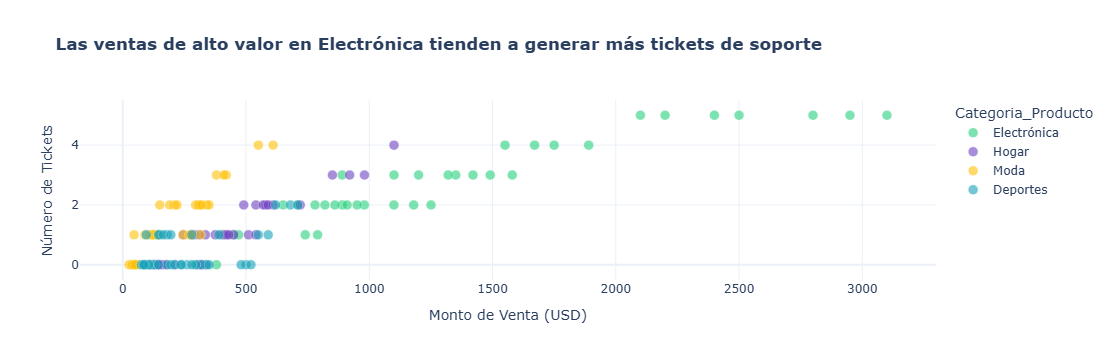

In [159]:
# grafico 2
# -------------------------------------------------------------------------------

# titulo y legendas
title = '<b>Las ventas de alto valor en Electrónica tienden a generar más tickets de soporte</b>'
labels = {
        _Monto_Venta_USD_: 'Monto de Venta (USD)', 
        _Tickets_Soporte_: 'Número de Tickets'}

# definimos la grafica
fig2 = px.scatter(df, 
                 x=_Monto_Venta_USD_, 
                 y=_Tickets_Soporte_,
                 color=_Categoria_Producto_,
                 title=title,
                 labels=labels,
                 render_mode="svg",
                 color_discrete_sequence=_paleta_tecmi,
                 hover_data=[_Nivel_Prioridad_],
                 template='plotly_white')

# definimos el tamaño de puntos y fondo del layout
fig2.update_traces(marker=dict(size=10, opacity=0.6, line=dict(width=0.5, color=_color_white)))
fig2.update_layout(plot_bgcolor=_color_white)
fig2.show()

### 📑 Justificación Técnica

Las variables utilizadas en el Gráfico de Dispersión son: 
- Monto de Venta, como variable continua.
- Tickets de Soporte, como variable discreta.
- Categoría vía color, como variable nominal.

En el gráfico se emplea el procesamiento preatentivo mediante el color para diferenciar categorías y la posición en ejes cartesianos para representar la relación. La transparencia en los puntos permite gestionar el solapamiento de datos.

Definitivamente el Scatter Plot es la herramienta estándar para detectar si una variable afecta a otra. Se eligió sobre un gráfico de líneas porque los datos no son temporales ni continuos entre registros.

## 📉 Visualizacion 3

Esta visualizacion tiene como objetivo el analizar cómo se distribuyen los montos de venta según el nivel de prioridad logística, identificando valores atípicos.

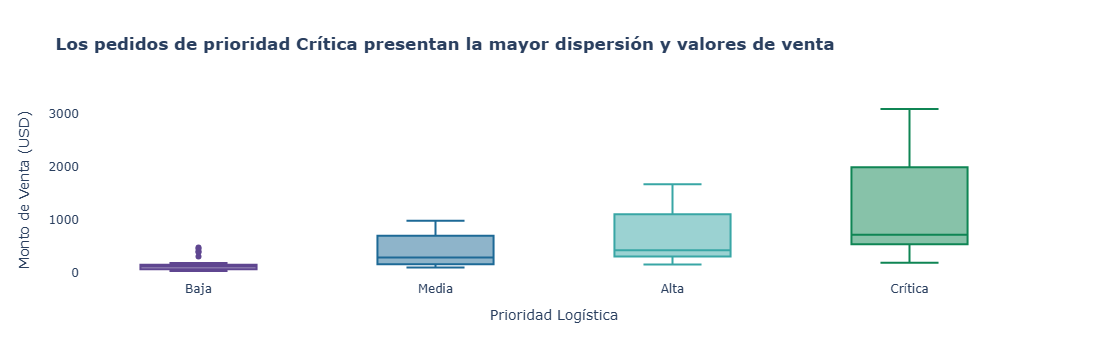

In [160]:
# grafico 3
# -------------------------------------------------------------------------------

# titulo y legendas
title = '<b>Los pedidos de prioridad Crítica presentan la mayor dispersión y valores de venta</b>'
labels = {
       _Monto_Venta_USD_: 'Monto de Venta (USD)', 
       _Nivel_Prioridad_: 'Prioridad Logística'}

# orden para la variable de prioridad
orden_prioridad = ['Baja', 'Media', 'Alta', 'Crítica']
orden_palette = [_color_gray, _color_tecmi_light, _color_info, _color_primary]

# grafica
fig3 = px.box(df, 
             x=_Nivel_Prioridad_, 
             y=_Monto_Venta_USD_,
             color=_Nivel_Prioridad_,
             category_orders={_Nivel_Prioridad_: orden_prioridad},
             title=title,
             color_discrete_sequence=px.colors.qualitative.Prism,
             labels=labels)

# se define el fondo del layout
fig3.update_layout(showlegend=False, plot_bgcolor=_color_white)
fig3.show()

### 📑 Justificación Técnica

En este gráfico se utilizaron las ariables: 
- Nivel de Prioridad, como variable ordinal.
- Monto de Venta, como variable continua.

En este gráfico se aplica la Ley de Similitud de la Gestalt mediante el uso de colores consistentes y respeta el orden lógico de la variable ordinal, desde un nivel Bajo a Crítico.

El Boxplot fue elegido para esta visualización por su alta densidad de información; a diferencia de una barra de promedio simple que oculta la volatilidad, el boxplot muestra valores atipicos y la asimetría de los datos. Además, el boxplot facilita una comparación directa y limpia entre los cuatro niveles de prioridad en un mismo plano visual. Esto permite al tomador de decisiones ver que la prioridad "Crítica" no es solo una etiqueta, sino que está respaldada por transacciones de mayor valor monetario.

## 📑 Resumen de Ajustes Técnicos

Se sustituyó la carga manual del dataset por una petición HTTP directa al repositorio de GitHub mediante Pandas.

Al usar Plotly, las gráficas se vuelven más interactivas y el usuario puede realizar hover sobre los puntos para obtener detalles específicos, como el ID del cliente o la categoría exacta, sin saturar el gráfico con etiquetas de texto.

Además de esto, y para efectos de una visualización efectiva de datos, la librería ofrece de forma nativa un diseño "limpio" que evita la sobresaturación. Facilita también la eliminación de bordes, sombras y efectos 3D que pueden distorsionar la percepción de las magnitudes, alineándose con las buenas prácticas del diseño.